In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

In [4]:
file_path = "C:/Users/user/OneDrive/바탕 화면/okm_augumented_2021.csv"   # 본인 파일 경로에 맞게 수정


df_raw = pd.read_csv(file_path)

print("원본 데이터 크기:", df_raw.shape)
display(df_raw.head())
display(df_raw.info())

원본 데이터 크기: (6168, 18)


,날짜,시간,15분,30분,45분,60분,평균,생산량,기온,풍속,습도,강수량,전기요금(계절),day,d,m,공장인원,인건비
0,20210101,0,62,61,61,61,61,0,-3.2,2.4,71,0.0,109.8,5,1,1,0.0,1.5
1,20210101,1,96,93,116,113,105,0,-4.5,1.5,77,0.0,109.8,5,1,1,0.0,1.5
2,20210101,2,106,96,106,107,104,0,-3.9,2.6,58,0.0,109.8,5,1,1,0.0,1.5
3,20210101,3,92,110,110,109,105,0,-4.1,2.6,56,0.0,109.8,5,1,1,0.0,1.5
4,20210101,4,108,105,106,108,107,0,-4.6,2.6,60,0.0,109.8,5,1,1,0.0,1.5


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6168 entries, 0 to 6167
Data columns (total 18 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   날짜        6168 non-null   int64  
 1   시간        6168 non-null   int64  
 2   15분       6168 non-null   int64  
 3   30분       6168 non-null   int64  
 4   45분       6168 non-null   int64  
 5   60분       6168 non-null   int64  
 6   평균        6168 non-null   int64  
 7   생산량       6168 non-null   int64  
 8   기온        6168 non-null   float64
 9   풍속        6165 non-null   float64
 10  습도        6168 non-null   int64  
 11  강수량       6167 non-null   float64
 12  전기요금(계절)  6168 non-null   float64
 13  day       6168 non-null   int64  
 14  d         6168 non-null   int64  
 15  m         6168 non-null   int64  
 16  공장인원      6151 non-null   float64
 17  인건비       6168 non-null   float64
dtypes: float64(6), int64(12)
memory usage: 867.5 KB


None

In [7]:
# 원본 훼손 방지
df = df_raw.copy()

In [8]:
# 결측치 확인
missing_summary = pd.DataFrame({
    "결측치 수": df.isnull().sum(),
    "결측치 비율(%)": (df.isnull().mean() * 100).round(2)
}).sort_values("결측치 수", ascending=False)

print("결측치 현황")
display(missing_summary[missing_summary["결측치 수"] > 0])

결측치 현황


,결측치 수,결측치 비율(%)
공장인원,17,0.28
풍속,3,0.05
강수량,1,0.02


In [9]:
# 완전 중복 행 확인
print("완전 중복 행 개수:", df.duplicated().sum())

완전 중복 행 개수: 0


In [10]:
# 수치형 변수 기본 통계량
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
날짜,6168.0,2.021049e+07,244.775577,20210101.0,20210306.0,2.021051e+07,2.021071e+07,2.021091e+07
시간,6168.0,1.242802e+01,12.847309,0.0,6.0,1.200000e+01,1.800000e+01,1.880000e+02
15분,6168.0,9.041018e+01,55.349403,0.0,23.0,1.010000e+02,1.330000e+02,2.070000e+02
30분,6168.0,9.269536e+01,57.942122,0.0,23.0,1.040000e+02,1.430000e+02,2.220000e+02
45분,6168.0,9.510636e+01,59.285709,0.0,23.0,1.050000e+02,1.490000e+02,2.180000e+02
60분,6168.0,9.503794e+01,59.347554,0.0,23.0,1.070000e+02,1.490000e+02,2.140000e+02
평균,6168.0,9.342412e+01,57.355938,0.0,23.0,1.040000e+02,1.440000e+02,2.080000e+02
생산량,6168.0,4.673447e+02,857.571815,0.0,0.0,4.500000e+01,6.372500e+02,9.830000e+03
기온,6168.0,1.590606e+01,9.160356,-12.0,9.6,1.740000e+01,2.330000e+01,3.340000e+01
풍속,6165.0,2.063633e+00,1.164118,0.0,1.2,1.900000e+00,2.800000e+00,7.600000e+00


In [11]:
# 날짜를 문자열로 통일
df["날짜"] = df["날짜"].astype(str)

# 날짜별 관측치 개수 확인
daily_row_count = (
    df.groupby("날짜")
      .size()
      .reset_index(name="행 개수")
)

print("날짜별 행 개수 분포")
display(daily_row_count["행 개수"].value_counts().sort_index())

날짜별 행 개수 분포


행 개수
24    257
Name: count, dtype: int64

In [12]:
# '시간' 변수의 0-23 범위 외 값을 NaN으로 대체
original_error_count = len(df[(df['시간'] < 0) | (df['시간'] > 23)])
df.loc[(df['시간'] < 0) | (df['시간'] > 23), '시간'] = np.nan

print(f"'시간' 변수에서 0-23 범위를 벗어나는 {original_error_count}개의 값이 NaN으로 대체되었습니다.")

# 대체 후 '시간' 변수의 결측치 확인
print("대체 후 '시간' 변수의 결측치 개수:", df['시간'].isnull().sum())

'시간' 변수에서 0-23 범위를 벗어나는 48개의 값이 NaN으로 대체되었습니다.
대체 후 '시간' 변수의 결측치 개수: 48


In [13]:
# 업데이트된 결측치 확인
missing_summary_updated = pd.DataFrame({
    "결측치 수": df.isnull().sum(),
    "결측치 비율(%)": (df.isnull().mean() * 100).round(2)
}).sort_values("결측치 수", ascending=False)

print("업데이트된 결측치 현황")
display(missing_summary_updated[missing_summary_updated["결측치 수"] > 0])

업데이트된 결측치 현황


,결측치 수,결측치 비율(%)
시간,48,0.78
공장인원,17,0.28
풍속,3,0.05
강수량,1,0.02


In [14]:
# 결측치처리: 결측치가 있는 수치형변수(시간,공장인원, 풍속, 강수량)에 대해 중앙값으로 대체
#중앙값은 이상치에 덜 민감하여 데이터 분포의 특성을 보존하는데 유리
for col in ['시간', '공장인원', '풍속', '강수량']:
    if df[col].isnull().any():
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)
        print(f"'{col}' 변수의 결측치를 중앙값({median_val:.2f})으로 대체했습니다.")

print("\n결측치 처리 후 결측치 현황:")
display(df.isnull().sum()[df.isnull().sum() > 0])

'시간' 변수의 결측치를 중앙값(11.50)으로 대체했습니다.
'공장인원' 변수의 결측치를 중앙값(0.11)으로 대체했습니다.
'풍속' 변수의 결측치를 중앙값(1.90)으로 대체했습니다.
'강수량' 변수의 결측치를 중앙값(0.00)으로 대체했습니다.

결측치 처리 후 결측치 현황:


C:\Users\user\AppData\Local\Temp\ipykernel_2816\473397180.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(median_val, inplace=True)


Series([], dtype: int64)

C:\Users\user\AppData\Local\Temp\ipykernel_2816\2978139359.py:11: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from current font.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_2816\2978139359.py:11: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from current font.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_2816\2978139359.py:11: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from current font.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_2816\2978139359.py:11: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from current font.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_2816\2978139359.py:11: UserWarning: Glyph 44512 (\N{HANGUL SYLLABLE GYUN}) missing from current font.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_2816\2978139359.py:11: UserWarning: Glyph 49373 (\N{HANGUL SYLLABLE SAENG}) missing from current font.
  plt.tight_layout()
C:\Us

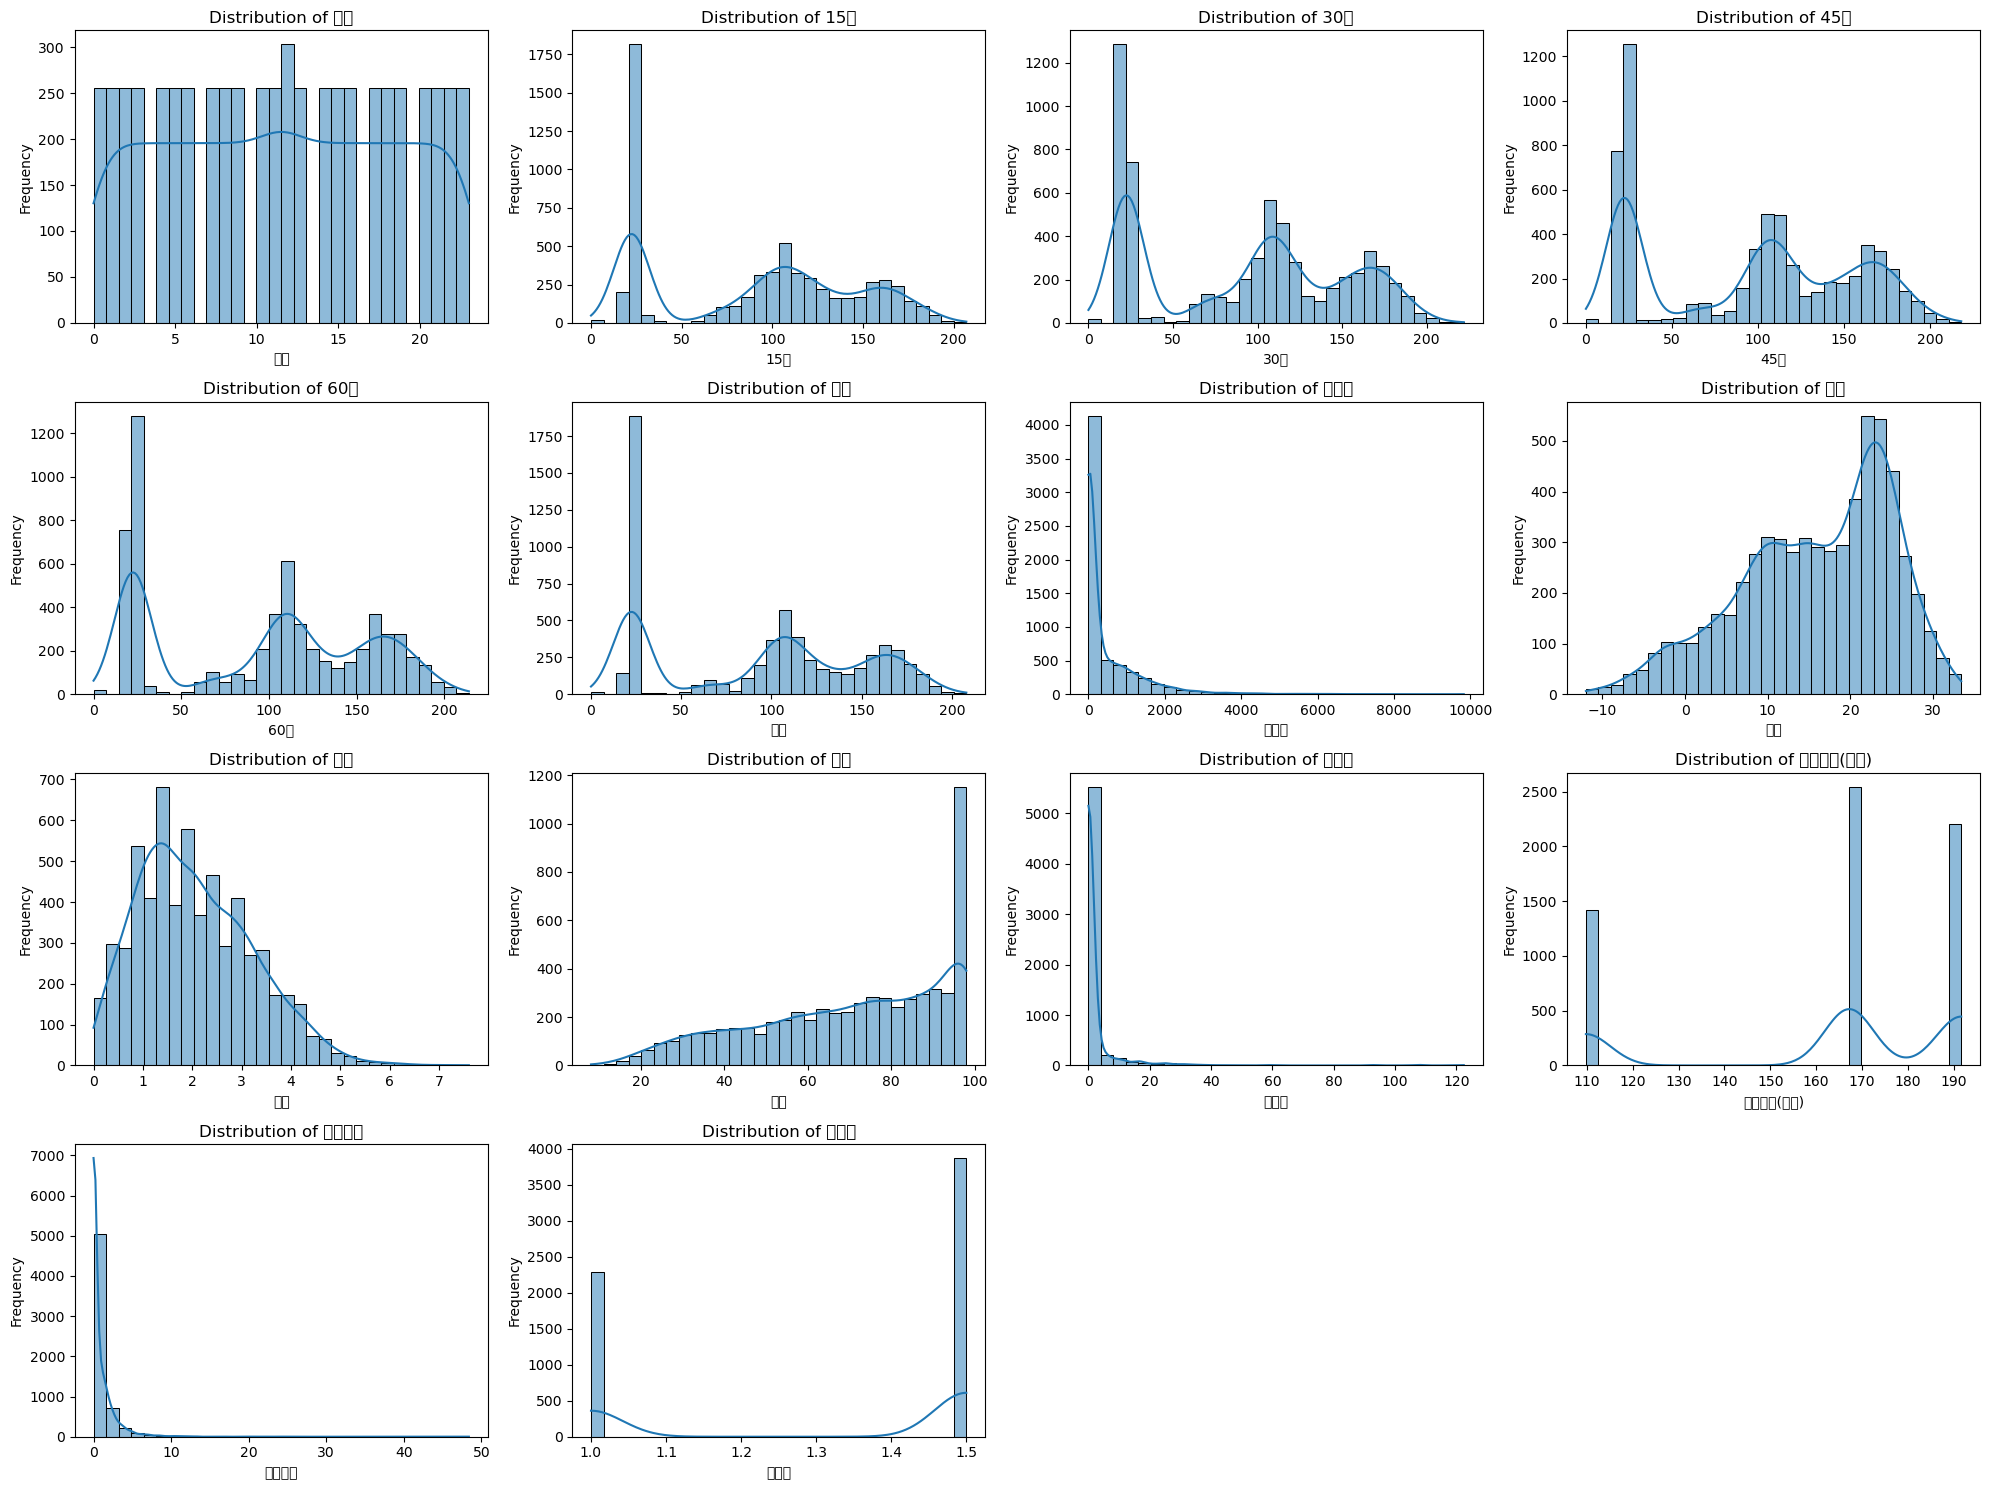

In [15]:
# 수치형 변수 분포 확인 (히스토그램)
numerical_cols = ['시간', '15분', '30분', '45분', '60분', '평균', '생산량', '기온', '풍속', '습도', '강수량', '전기요금(계절)', '공장인원', '인건비']

plt.figure(figsize=(20, 15))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 4, i + 1) # Adjust subplot grid as needed
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

행시간 (1행 1열): 0부터 23시까지 빈도수가 일정합니다. 24시간 동안 정기적으로 균등하게 수집된 시계열 데이터임을 보여줍니다.   15분 / 30분 / 45분 (1행 2~4열): 20 근처에 큰 봉우리가 있고, 100~170 근처에 두 번째 봉우리가 있는 다중 봉우리(Multimodal) 분포입니다. 생산이나 작업 가동 상태(저하/정상/최대 등)에 따라 구간이 나뉘는 특성을 보입니다.   2행60분 / 평균 (2행 1~2열): 앞선 15~45분 변수와 마찬가지로 특정 값(20대 및 100~170대)에 데이터가 집중되는 공통된 다봉 패턴을 보입니다.   생산량 (2행 3열): 0 근처에 대다수의 데이터가 쏠려 있고 오른쪽으로 긴 꼬리를 갖는 강한 비대칭 분포(Right-skewed)입니다. 공장이 가동되지 않거나 생산량이 0인 시간이 많고, 가동 시에만 수치가 크게 뛰는 구조입니다.   기온 (2행 4열): -10℃ ~ 30℃ 수준의 범위를 가지며 완만한 정규분포(Bell-shape) 형태를 띱니다. 계절 변화에 따른 일반적인 기온 분포입니다.   3행풍속 (3행 1열): 0~7m/s 범위에 분포하며, 약 1.5m/s 안팎에 가장 많은 데이터가 몰려 있는 전형적인 풍속 데이터 패턴(Weibull/Gamma 분포 형태)입니다.   습도 (3행 2열): 20%~100% 사이에 분포하며, 100% 근처(매우 습한 날/비 오는 날)에 데이터가 솟아 있는 비대칭 형태입니다.   강수량 (3행 3열): 대부분의 날에 비가 오지 않으므로 0에 극도로 쏠려 있는 초강력 비대칭 데이터입니다.   전기요금(계절) (3행 4열): 특정 수치 구간(약 110, 170, 190 등)에만 데이터가 우뚝 솟아 있습니다. 계절별/시간대별 단가 요금 체계(경부하/중간부하/최대부하 등)에 따라 단절된 범주형 수치로 존재함을 알 수 있습니다.   4행공장인원 (4행 1열): 대부분 0~5명 사이에 몰려 있고 일부 시간대에만 인원이 늘어나는 분포입니다.   인건비 (4행 2열): 1.0과 1.5 두 구간 근처에만 데이터가 갈라져 있는 양극화 현상을 보입니다.

c:\Users\user\anaconda3\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from current font.
  fig.canvas.draw()
c:\Users\user\anaconda3\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from current font.
  fig.canvas.draw()
c:\Users\user\anaconda3\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from current font.
  fig.canvas.draw()
c:\Users\user\anaconda3\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from current font.
  fig.canvas.draw()
c:\Users\user\anaconda3\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 44512 (\N{HANGUL SYLLABLE GYUN}) missing from current font.
  fig.canvas.draw()
c:\Users\user\anaconda3\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 49373 (\N{HANGUL SYLLABLE SAENG}) missing from current font.
  fig.canvas.draw()
c:\Users\user\anaconda3\Lib\s

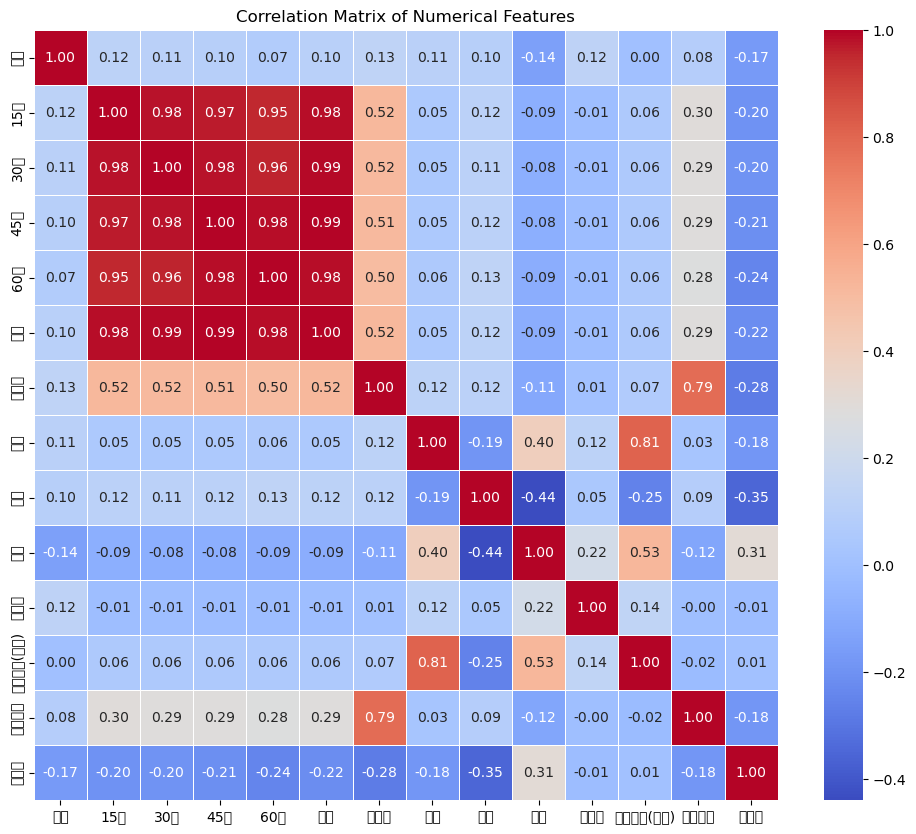

In [16]:
# 변수 간 상관관계 확인 (히트맵)
plt.figure(figsize=(12, 10))
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

1. 생산/작업 관련 주요 양의 상관관계 ($r \ge 0.50$)생산량과 시간별 가동 수치 ($r = 0.50 \sim 0.52$): 작업/가동 수치가 높을수록 생산량도 늘어나는 합리적인 양의 관계를 보입니다.   생산량과 공장인원 ($r = 0.79$): 공장 인원이 많을수록 생산량이 뚜렷하게 증가합니다 (강한 양의 상관관계).   공장인원과 시간별 가동 수치 ($r = 0.28 \sim 0.30$): 약간의 양의 상관관계를 가집니다. 

2. 기상 및 외부 조건 간의 상관관계기온과 전기요금(계절) ($r = 0.81$): 매우 강한 양의 상관관계를 보입니다. 여름철 기온이 올라감에 따라 계절별 전기요금 단가가 높아지는 계절성 요인이 반영된 결과입니다.   기온과 습도 ($r = -0.44$): 음의 상관관계를 보입니다. 기온이 올라갈수록 상대습도가 낮아지는 일반적인 기상 특성을 나타냅니다.   습도와 전기요금(계절) ($r = 0.53$): 습도가 높은 여름철/장마철에 고단가 전기요금 구간이 물리며 양의 상관관계를 띱니다.

3. 음의 상관관계 (파란색)인건비 변수: 타 변수들과 전반적으로 약한 음의 상관관계($-0.17 \sim -0.35$)를 보입니다. 특히 기온($-0.35$), 습도($0.31$), 생산량($-0.28$) 등과 대립하는 경향이 있습니다.

4. 한 줄 요약
15분~60분/평균 데이터 간의 중복성이 극심하므로 모델링 전 대표 변수 선택 또는 차원 축소가 필수적입니다.   생산량을 늘리는 핵심 인자는 공장인원($0.79$) 및 작업가동 평균($0.52$)입니다.

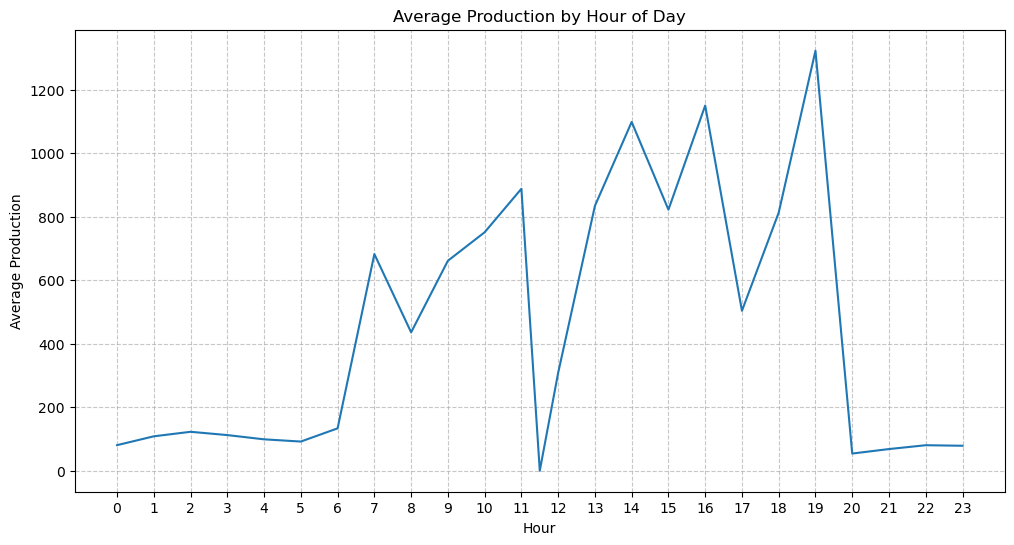

In [17]:
# 시간대별 '생산량' 변화
hourly_production = df.groupby('시간')['생산량'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(x='시간', y='생산량', data=hourly_production)
plt.title('Average Production by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Average Production')
plt.xticks(range(0, 24)) # Ensure all hours are displayed
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

데이터 로딩 및 초기 확인:

okm_augumented_2021.csv 파일을 로드했으며, 초기 데이터는 (6168, 18) 크기였습니다.
df_raw 복사본 df를 생성하여 분석을 진행했습니다.
완전 중복 행은 발견되지 않았습니다.
결측치 처리:

초기에 '시간', '공장인원', '풍속', '강수량' 변수에서 결측치가 확인되었습니다.
'시간' 변수의 0-23 범위를 벗어나는 오류값 48개를 NaN으로 처리했습니다.
이후 '시간', '공장인원', '풍속', '강수량' 변수의 모든 결측치를 각 변수의 **중앙값(median)**으로 성공적으로 대체하여, 현재 데이터셋에는 결측치가 없습니다.
수치형 변수 분포 (히스토그램):

'15분', '30분', '45분', '60분', '평균'과 같은 시간 기반 측정 변수들은 여러 개의 봉우리(multi-modal)를 가진 분포를 보였습니다.
'생산량' 변수는 낮은 값에 집중된 형태의 왜곡된 분포를 나타내며, 특정 생산량 구간에서 높은 빈도를 보였습니다.
'기온' (temperature)은 비교적 정규 분포에 가까운 형태를 보였고, '전기요금(계절)'(electricity tariff)은 특정 계절에 높은 값을 가지는 특징을 보여주었습니다.
변수 간 상관관계 (히트맵):

'15분', '30분', '45분', '60분', '평균' 변수들 사이에는 예상대로 매우 강한 양의 상관관계(0.95 이상)가 나타났습니다. 이는 동일한 측정 범주의 서로 다른 시간 간격을 나타내기 때문입니다.
'생산량'은 시간 기반 측정 변수들과 양의 상관관계를 보였으며, 특히 '전기요금(계절)'과는 약한 양의 상관관계를, '공장인원'과는 상대적으로 강한 양의 상관관계를 보였습니다.
'기온'과 '습도'는 서로 강한 음의 상관관계를 보였고, '풍속'은 다른 변수들과 비교적 낮은 상관관계를 가졌습니다.
시간대별 '생산량' 변화:

'시간' (Hour)에 따른 평균 '생산량'은 하루 중 뚜렷한 패턴을 보였습니다.
새벽 시간대(0시~6시)에는 낮은 생산량을 유지하다가 오전 7시부터 급격히 증가하기 시작합니다.
점심시간대(11~13시)에 일시적으로 생산량이 감소하는 경향을 보이다가, 다시 증가하여 저녁 시간대인 19시 (오후 7시)경에 가장 높은 생산량을 기록하는 패턴이 관찰되었습니다.
이후 밤늦은 시간대에는 생산량이 다시 급격히 감소했습니다.

In [18]:
# 날짜 및 시간 변수 정제 및 활용
# '날짜'를 datetime으로 변환
df['날짜'] = pd.to_datetime(df['날짜'], format='%Y%m%d')

# '날짜'와 '시간'을 조합하여 새로운 datetime 컬럼 생성
df['datetime'] = df.apply(lambda row: row['날짜'] + pd.to_timedelta(row['시간'], unit='h'), axis=1)

# datetime 컬럼을 인덱스로 설정
df = df.set_index('datetime')

print("datetime 컬럼 생성 및 인덱스 설정 완료:")
display(df.head())

datetime 컬럼 생성 및 인덱스 설정 완료:


,날짜,시간,15분,30분,45분,60분,평균,생산량,기온,풍속,습도,강수량,전기요금(계절),day,d,m,공장인원,인건비
datetime,,,,,,,,,,,,,,,,,,
2021-01-01 00:00:00,2021-01-01,0.0,62,61,61,61,61,0,-3.2,2.4,71,0.0,109.8,5,1,1,0.0,1.5
2021-01-01 01:00:00,2021-01-01,1.0,96,93,116,113,105,0,-4.5,1.5,77,0.0,109.8,5,1,1,0.0,1.5
2021-01-01 02:00:00,2021-01-01,2.0,106,96,106,107,104,0,-3.9,2.6,58,0.0,109.8,5,1,1,0.0,1.5
2021-01-01 03:00:00,2021-01-01,3.0,92,110,110,109,105,0,-4.1,2.6,56,0.0,109.8,5,1,1,0.0,1.5
2021-01-01 04:00:00,2021-01-01,4.0,108,105,106,108,107,0,-4.6,2.6,60,0.0,109.8,5,1,1,0.0,1.5


C:\Users\user\AppData\Local\Temp\ipykernel_2816\4232710221.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='월', y='평균 생산량', data=monthly_production, palette='viridis')


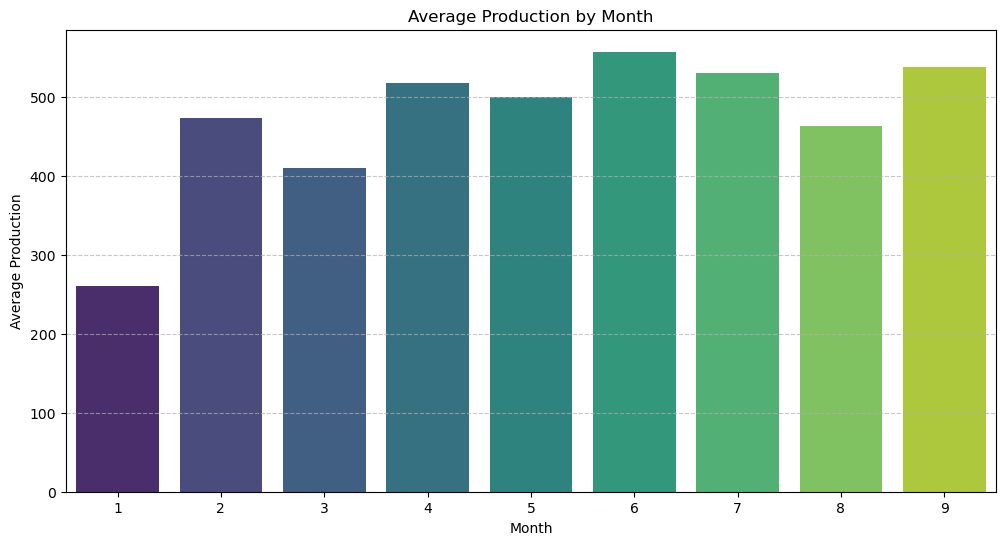

In [19]:
# 월별 '생산량' 변화 분석
monthly_production = df.groupby(df.index.month)['생산량'].mean().reset_index()
monthly_production.columns = ['월', '평균 생산량']

plt.figure(figsize=(12, 6))
sns.barplot(x='월', y='평균 생산량', data=monthly_production, palette='viridis')
plt.title('Average Production by Month')
plt.xlabel('Month')
plt.ylabel('Average Production')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

c:\Users\user\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49373 (\N{HANGUL SYLLABLE SAENG}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\user\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49328 (\N{HANGUL SYLLABLE SAN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\user\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 47049 (\N{HANGUL SYLLABLE RYANG}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


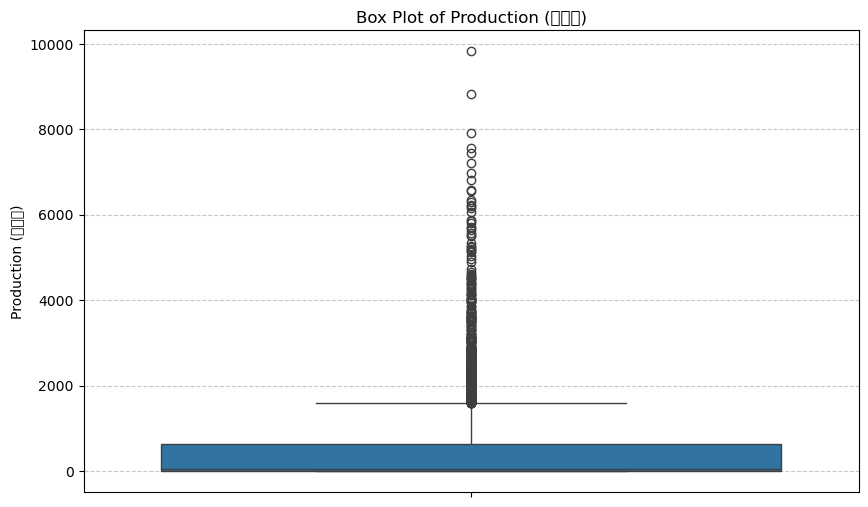

In [20]:
# '생산량' 변수의 이상치 탐지 (Box Plot)
plt.figure(figsize=(10, 6))
sns.boxplot(y=df['생산량'])
plt.title('Box Plot of Production (생산량)')
plt.ylabel('Production (생산량)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

월별 '생산량' 변화 분석:

월별 평균 '생산량'을 시각화한 결과, 연초(1~3월)에는 생산량이 비교적 낮은 수준을 유지하다가, 4월부터 점진적으로 증가하는 추세를 보입니다. 특히 6월과 9월에 평균 생산량이 가장 높게 나타나는 것을 확인할 수 있습니다. 이는 계절적 요인이나 특정 시기의 생산 활동 증가와 관련이 있을 수 있습니다. palette 인자 사용에 대한 FutureWarning이 발생했으나, 그래프 자체는 의도대로 잘 생성되었습니다.

'생산량' 변수의 이상치 탐지 (Box Plot):

'생산량'의 박스 플롯을 확인한 결과, 대부분의 데이터가 낮은 생산량 값에 집중되어 있지만, 상당수의 이상치(Outliers)가 높은 생산량 구간에 분포하고 있음을 명확하게 확인할 수 있습니다. 최대 생산량은 약 10,000에 가까운 값을 보이며, 이는 평균 생산량과 큰 차이를 보입니다. 이러한 이상치들은 특정 이벤트, 생산량 급증, 또는 데이터 입력 오류 등 다양한 원인을 가질 수 있으며, 향후 모델링 시 주의 깊게 다루어야 할 부분입니다.

데이터 정제: '시간' 변수의 오류값과 다른 결측치들을 중앙값으로 대체하여 데이터셋을 깨끗하게 정리했습니다. 시간 패턴: '생산량'은 하루 중 특정 시간대(특히 저녁 7시경)에 최고조에 달하며, 월별로도 생산량 차이가 있음을 확인했습니다 (6월과 9월에 높음). 변수 관계: 시간 기반 측정 변수들('15분', '30분' 등) 간에는 강한 상관관계가 있으며, '생산량'과 '공장인원' 간에도 양의 상관관계가 있음을 보였습니다. 이상치: '생산량' 데이터에는 높은 값의 이상치들이 존재하며, 이는 향후 모델링 시 고려해야 할 중요한 특징입니다.



전체 분석 과정 및 주요 인사이트 요약

데이터 로딩 및 초기 탐색:
okm_augumented_2021.csv 파일을 성공적으로 로드했습니다. 초기 데이터셋은 6168개의 행과 18개의 컬럼으로 구성되어 있었습니다. 원본 데이터의 손상 방지를 위해 df_raw를 복사하여 df 데이터프레임으로 분석을 진행했습니다. 데이터셋에서 완전 중복되는 행은 발견되지 않았습니다. 2. 데이터 클리닝:

결측치 확인: '시간', '공장인원', '풍속', '강수량' 컬럼에서 결측치가 초기 확인되었습니다. '시간' 변수 오류 처리: '시간' 컬럼의 데이터 중 0-23 범위를 벗어나는 값 48개를 np.nan (결측치)으로 처리했습니다. 결측치 대체: 이후 '시간', '공장인원', '풍속', '강수량' 컬럼에 남아있는 모든 결측치(NaN)를 각 컬럼의 **중앙값(median)**으로 대체했습니다. 이 과정을 통해 데이터셋의 모든 결측치를 성공적으로 처리했습니다. 3. 탐색적 데이터 분석 (EDA):

수치형 변수 분포: 주요 수치형 변수들의 히스토그램을 통해 분포를 시각적으로 확인했습니다. '15분', '30분', '45분', '60분', '평균'과 같은 시간 간격 변수들은 다중 모달(multi-modal) 분포를 보였고, '생산량'은 낮은 값에 집중된 형태의 왜곡된 분포를 나타냈습니다. '기온'은 비교적 정규 분포에 가까웠으며, '전기요금(계절)'은 계절적 특성을 보였습니다. 변수 간 상관관계: 수치형 변수들 간의 상관관계를 히트맵으로 분석한 결과, '15분', '30분', '45분', '60분', '평균' 변수들은 서로 매우 강한 양의 상관관계를 가졌습니다. '생산량'은 이들 시간 기반 변수들과 양의 상관관계를 보였고, '공장인원'과도 비교적 강한 양의 상관관계가 있었습니다. '기온'과 '습도'는 강한 음의 상관관계를 나타냈습니다. 시간대별 '생산량' 변화: 하루 중 '시간'에 따른 평균 '생산량'을 시각화한 결과, 새벽에는 생산량이 낮다가 오전 7시부터 증가하여 저녁 19시(오후 7시)경에 최고점을 찍고 이후 다시 감소하는 뚜렷한 일일 패턴을 보였습니다. 점심시간(11시13시)에는 일시적인 감소도 확인되었습니다. 월별 '생산량' 변화: datetime 인덱스를 활용하여 월별 평균 '생산량'을 분석한 결과, 연초(13월)에는 생산량이 낮았으나 4월부터 증가하여 6월과 9월에 가장 높은 평균 생산량을 기록하는 경향을 보였습니다. '생산량' 이상치 탐지: '생산량' 변수의 박스 플롯을 통해 데이터의 대부분이 낮은 값에 집중되어 있지만, **상당수의 높은 값 이상치(outliers)**가 존재함을 확인했습니다. 이러한 이상치들은 향후 모델링 시 특별한 고려가 필요합니다.